In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

from mad.objs.constants import G0, titan_stage_1, titan_stage_2, EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig, SimulationInterface
from mad.objs.common_schemas import MovableObject, History
from mad.objs.projectiles import ProjectileConfig, Projectile
from mad.objs.missiles import MissileConfig, MissileStage, StageConfig
from mad.logger import SourceLogger
from copy import deepcopy

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(-9.819649737724955))

In [4]:


class BallisticMissile(SimulationInterface, MovableObject):
    def __init__(self, cfg: MissileConfig):
        super().__init__(position=cfg.position, name = cfg.name)

        self.stages = cfg.stages
        self.guidance = cfg.guidance
        self.t = 0
        self.history = History()
        self.initial_mass = deepcopy(self.mass)
        self.final_mass = sum(stage.dry_mass for stage in self.stages)

    @property
    def mass(self):
        return sum(stage.mass for stage in self.stages)

    @property
    def area(self):
        return sum(stage.area for stage in self.stages)

    @property
    def Cd(self):
        return sum(stage.Cd for stage in self.stages)

    @property
    def deltav(self):
        dv_total = 0.0

        for i, stage in enumerate(self.stages):
            m0 = sum(s.mass for s in self.stages[i:])
            mf = m0 - stage.propellant_mass
            isp = stage.Isp
            dv = isp * G0 * np.log(m0 / mf)
            dv_total += dv

        return dv_total
    
    def burned_fraction(self):
        return (self.initial_mass - self.mass) / (self.initial_mass - self.final_mass)

    def ballistic_range(self, planet:Planet, gamma_deg:float=30):
        # Helper to quickly determine the range of the missile.

        gamma = np.radians(gamma_deg)
        # Taking 0.8 to estimate for drag / gravity / steering losses
        deltav = 0.8 * self.deltav  
        num = deltav**2 * np.sin(gamma) * np.cos(gamma)
        den = planet.mu / planet.radius - deltav**2 * np.sin(gamma) ** 2
        central_angle = 2 * np.arctan(num / den)

        return planet.radius * central_angle

    def __repr__(self):
        a = "active" if self.active else "inactive"
        return f"BallisticMissile {self.name}, deltaV {self.deltav} m/s, {a}."

    def optimal_gamma(self, planet:Planet, sigma:NDArray):
        return np.arctan((self.deltav**2 - planet.mu / planet.radius) / self.deltav**2 * np.tan(sigma / 2))

    def get_guidance(self, target, planet)->NDArray:

        sigma = self.central_angle(target)
        gamma = self.optimal_gamma(planet, sigma)

        return self.desired_direction(target, gamma)
    
    def gravity_turn_direction(self, target, optimal_gamma, fraction):

        r_hat, t_hat = self.local_frame(target)

        # smooth rotation from vertical to target direction
        theta = optimal_gamma * (1 - np.cos(np.pi/2 * fraction))

        d = np.cos(theta) * r_hat + np.sin(theta) * t_hat
        return d / np.linalg.norm(d)


    def thrust_acc(self):

        running_stage = self.stages[0]
        if not running_stage.active:
            return np.zeros_like(self.position)

        direction = self.get_guidance()

        T = running_stage.thrust

        return direction * (T / self.mass)

    def update(self, dt: float) -> None | Projectile:
        self.t += dt
        running_stage = self.stages[0]
        running_stage.update(dt)

        if not running_stage.active:
            stage_cfg = ProjectileConfig(position = self.position.tolist(), 
                                            velocity = self.velocity.tolist(),
                                            mass = running_stage.dry_mass,
                                            name = running_stage.name,
                                            area = running_stage.area,
                                            Cd = running_stage.Cd,
                                            )

            del(self.stages[0])
            logger["Missile"].info(f"{self.name} - {running_stage.name} separated at {self.t:.2f}.")
            if len(self.stages) == 0: 
                self.active = False
                logger["Missile"].info(f"{self.name} inactivated at {self.t:.2f}.")
            return Projectile(stage_cfg)
        else:
            return None

    def accelerations(self, planet: Planet) -> NDArray:
        gravity = planet.gravity(self)
        drag = planet.drag(self)
        thrust = self.thrust_acc()

        return gravity + drag + thrust

    def integrate(self, dt: float, planet: Planet) -> None:
        # Velocity Verlet for solver.
        a0 = self.accelerations(planet)
        self.position += self.velocity * dt + 0.5 * a0 * dt**2
        a1 = self.accelerations(planet)

        self.velocity += 0.5 * (a0 + a1) * dt

        self.history.position.append(self.position.tolist())
        self.history.velocity.append(self.velocity.tolist())

In [5]:
titan_stage_1.update({"dry_mass":10_000, "propellant_mass":100_000, "Isp":285})
titan_stage_2.update({"dry_mass": 2_000, "propellant_mass": 20_000, "Isp": 300})



In [6]:
stage1 = MissileStage(StageConfig(**titan_stage_1))
stage2 = MissileStage(StageConfig(**titan_stage_2))


mis_pos = [earth.radius + 10, 0.0]
titan = BallisticMissile(MissileConfig(position = mis_pos, stages = [stage1, stage2], name="Titan I"))

In [7]:
f"dV={titan.deltav:.2f} m/s, range={titan.ballistic_range(earth, gamma_deg=45)/1000:4.2f} km"

'dV=11015.15 m/s, range=13023.83 km'

In [8]:
dt = 1
active_objs = [titan]
inactive_objs = []
time_scale = [0.0]
for t in range(20000):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)
        time_scale.append(dt)

    active_objs.extend(new_objects)

TypeError: BallisticMissile.get_guidance() missing 2 required positional arguments: 'target' and 'planet'

In [81]:
def extract_history(objs:list):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)

        posx, posz = pos[:, 0], pos[:, 1]
        velx, velz = vel[:, 0], vel[:, 1]

        altitude = np.sqrt(posx**2 + posz**2) - earth.radius
        velout = np.sqrt(velx**2 + velz**2)

        results[obj.name] = {"altitude": altitude, "velocity":velout, "posx":posx, "posz":posz}

    return results

results = extract_history(active_objs)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

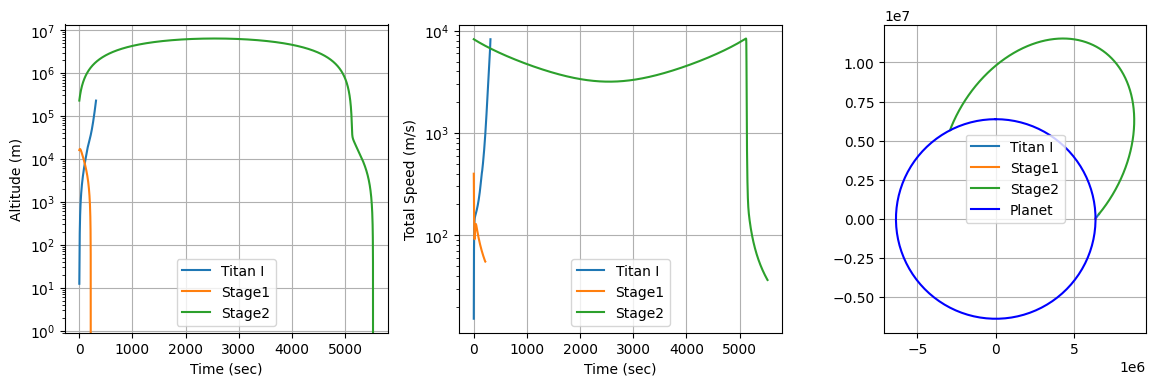

In [82]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

for obj, result in results.items():

    ax[0].semilogy(result["altitude"], label=obj)
    ax[1].semilogy(result["velocity"], label=obj)
    ax[2].plot(result["posx"], result["posz"], label=obj)

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (m)")
ax[0].grid()
ax[0].legend()

theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].set_aspect("equal")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)